### **שימו לב - ברגע שאתם מעלים את המחברת לגיטהאב שלכם תמחקו את ה key!**



In [1]:
pip install paho-mqtt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.5 MB/s eta 0:00:00


In [2]:
import paho.mqtt.client as mqtt
import json

# Callback function for when a message is received
def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())

        # Extract values with lowercase field names
        temperature = data.get("temperature", "N/A")
        humidity = data.get("humidity", "N/A")
        soil= data.get("soil", "N/A")
        print(f"Temperature: {temperature}°C, Humidity: {humidity}%")

    except json.JSONDecodeError:
        print("Received invalid JSON data")
        # MQTT setup
broker = "io.adafruit.com"
username = "braude5"   #insert Adafruit user name
aio_key = "" #insert key from Adafruit
topic = f"{username}/feeds/json"
client = mqtt.Client()
client.username_pw_set(username,aio_key)
client.on_message = on_message

client.connect(broker, 1883, 60)
client.subscribe(topic)

print(f"Subscribed to MQTT topic: {topic}")
client.loop_forever()



/tmp/ipykernel_20012/3065752362.py:22: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Subscribed to MQTT topic: braude5/feeds/json
Temperature: 25.3°C, Humidity: 47.0%
Temperature: 25.3°C, Humidity: 47.0%
Temperature: 25.3°C, Humidity: 47.0%


KeyboardInterrupt: 

In [3]:
import requests

USERNAME = "braude5"   #insert Adafruit user name
AIO_KEY = "" #insert key from Adafruit
FEED = "json"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

for item in data[:50]:  # חמשת הנתונים האחרונים
    print(f"Value: {item['value']}, Time: {item['created_at']}")


Value: {"temperature": 25.30, "humidity": 47.00, "tempThreshold": 0.00, "humThreshold": 25.00}, Time: 2026-05-13T09:18:38Z
Value: {"temperature": 25.30, "humidity": 47.00, "tempThreshold": 0.00, "humThreshold": 25.00}, Time: 2026-05-13T09:18:28Z
Value: {"temperature": 25.30, "humidity": 47.00, "tempThreshold": 0.00, "humThreshold": 25.00}, Time: 2026-05-13T09:18:18Z
Value: {"temperature": 25.30, "humidity": 47.00, "tempThreshold": 0.00, "humThreshold": 25.00}, Time: 2026-05-13T09:18:11Z
Value: {"temperature": 25.30, "humidity": 47.00, "tempThreshold": 0.00, "humThreshold": 25.00}, Time: 2026-05-13T09:17:59Z
Value: {"temperature": 25.30, "humidity": 47.00, "tempThreshold": 0.00, "humThreshold": 25.00}, Time: 2026-05-13T09:17:58Z
Value: {"temperature": 25.30, "humidity": 47.00, "tempThreshold": 0.00, "humThreshold": 25.00}, Time: 2026-05-13T09:17:38Z
Value: {"temperature": 25.30, "humidity": 47.00, "tempThreshold": 0.00, "humThreshold": 25.00}, Time: 2026-05-13T09:17:32Z
Value: {"tempera

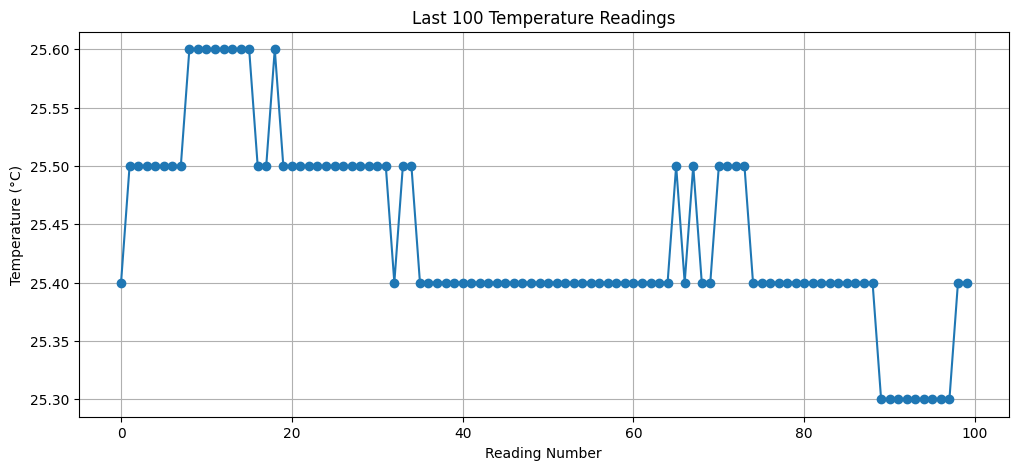

In [6]:
import requests
import json
import matplotlib.pyplot as plt

USERNAME = "braude5"
AIO_KEY = ""
FEED = "json"

url = f"https://io.adafruit.com/api/v2/{USERNAME}/feeds/{FEED}/data?limit=100"
headers = {"X-AIO-Key": AIO_KEY}

response = requests.get(url, headers=headers)
data = response.json()

temperatures = []

for item in data[::-1]:
    value_as_text = item["value"]
    value_as_json = json.loads(value_as_text)

    temperature = value_as_json["temperature"]
    temperatures.append(float(temperature))

plt.figure(figsize=(12, 5))
plt.plot(temperatures, marker="o")
plt.title("Last 100 Temperature Readings")
plt.xlabel("Reading Number")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()